# 1. Limpieza de Datos

In [1]:
import pandas as pd
import numpy as np
import os

In [12]:
df = pd.read_csv('data/titanic.csv')
df_2 = pd.read_csv('data/titanic_leccion.csv')

In [ ]:
#obtener una muestra aleatoria de 3 filas de cada dataframe para verificar su contenido
df.sample(3)
df_2.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
812,813,0,2,"Slemen, Mr. Richard James",male,35.0,0,0,28206,10.5,NaN,S
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0,B102,S
750,751,1,2,"Wells, Miss. Joan",female,4.0,1,1,29103,23.0,NaN,S


In [ ]:
#el dataframe de github ya esta limpio, por ello se bajo nueva copia de la pagina de hybridge para hacer los ejercicios (df_2).
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 
print(f"El shape del conjunto de entrenamiento es {df_2.shape}. {df_2.shape[0]} filas y {df_2.shape[1]} columnas.")

El shape del conjunto de entrenamiento es (891, 8). 891 filas y 8 columnas.
El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [ ]:
#el dataframe de github ya esta limpio, por ello se bajo nueva copia de la pagina de hybridge para hacer los ejercicios (df_2).
df.info()
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-nu

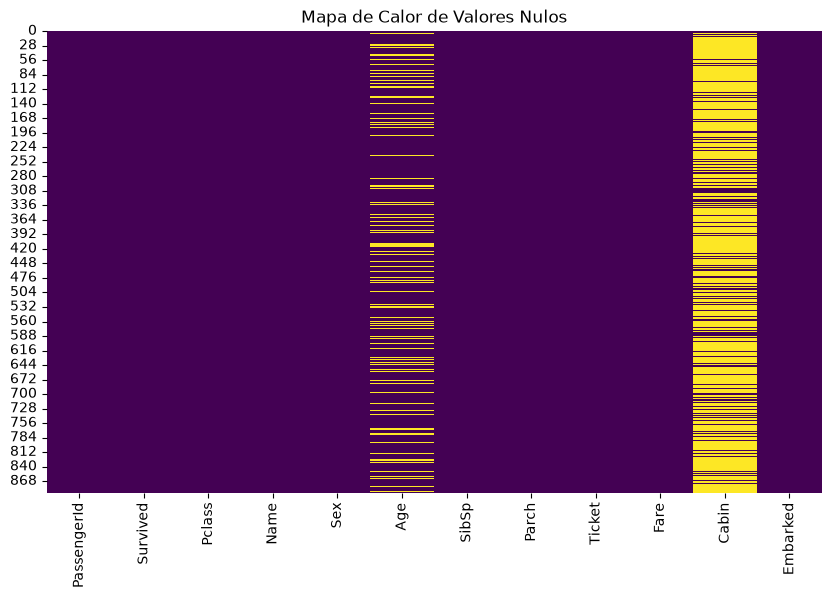

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

# dataframe se llama 'df_2'
plt.figure(figsize=(10, 6))
sns.heatmap(df_2.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')

# Guardar el gráfico como un archivo PNG
plt.savefig('output.png', format='png')

# Mostrar el gráfico
plt.show()

In [ ]:
#porcentaje de valores faltantes en df
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
#df fue sobrescrito en el repo original y muestra 0, por ello se bajo nueva copia de la pagina de hybridge para hacer los ejercicios.
print(missing_values_percentage)

Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64


In [ ]:
#porcentaje de valores faltantes en df_2
missing_values_percentage = df_2.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


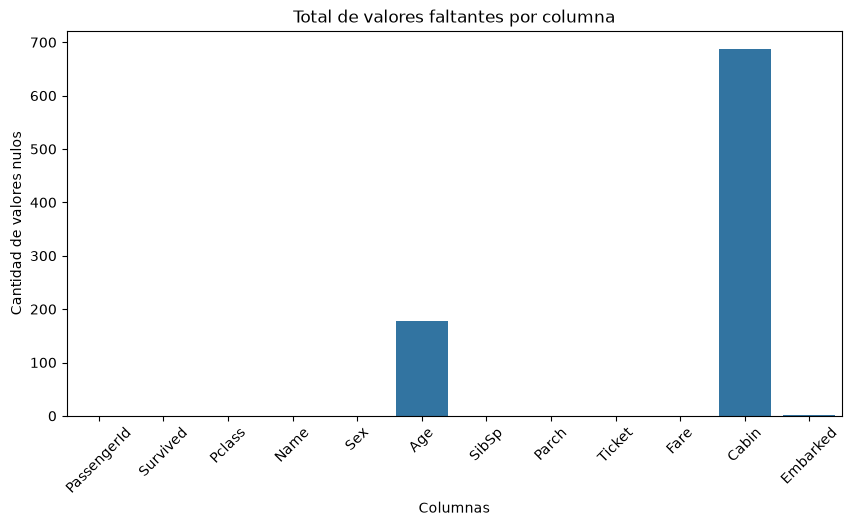

In [28]:
#grafica de barras
import matplotlib.pyplot as plt
import seaborn as sns

# Contar valores nulos por columna
missing_values = df_2.isnull().sum()

# Crear gráfica
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values)

plt.title('Total de valores faltantes por columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de valores nulos')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#corregir valores faltantes Cabin
df_2.drop('Cabin', axis = 1, inplace = True)

In [31]:
#corregir valores faltantes Age
# Reemplazar valores nulos de Age por la mediana
df_2['Age'] = df_2['Age'].fillna(df_2['Age'].median())

In [32]:
#corregir los valores Embarked
# Reemplazar valores nulos de Embarked por la moda
df_2['Embarked'] = df_2['Embarked'].fillna(df_2['Embarked'].mode()[0])

In [35]:
#porcentajes de valores nulos
round(df_2.isnull().sum().sort_values(ascending = False) / len(df_2) * 100, 2)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [36]:
#porcentajes nulos, total por columna
df_2.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [37]:
#verificacion valores duplicados
df_2.duplicated().sum()

np.int64(0)

In [39]:
#eliminar columnas name, ticket, passengerid
df_2.drop('Name', axis = 1, inplace = True)
df_2.drop('Ticket', axis = 1, inplace = True)
df_2.drop('PassengerId', axis = 1, inplace = True)

print(f"Después de limpiar df_2: {df_2.shape[0]} filas y {df_2.shape[1]} columnas.")

KeyError: "['Name'] not found in axis"

In [ ]:
print(f"Después de limpiar df_2: {df_2.shape[0]} filas y {df_2.shape[1]} columnas.")

#Después de limpiar df_2: 891 filas y 8 columnas.

Después de limpiar df_2: 891 filas y 8 columnas.


In [42]:
#guardar en directorio
df_2.to_csv('./data/titanic_limpio ejercicio.csv', index=False)

In [15]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [34]:
#valores nulos del dataframe en github 
print("Valores nulos por columna dataframe github")
print(df.isnull().sum())

#valores nulos del dataframe en pagina hybridge 
print("Valores nulos por columna dataframe pagina hybridge")
print(df_2.isnull().sum())

Valores nulos por columna dataframe github
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Valores nulos por columna dataframe pagina hybridge
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Tratamiento de Nulos

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


df.to_csv('data/titanic_clean.csv', index=False)
print("Datos guardados en data/titanic_clean.csv")

Datos guardados en data/titanic_clean.csv


In [6]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'os', '_i2', 'df', '_i3', '_3', '_i4', '_i5', '_i6'])
